# Day 9 & 11: Churn Prediction with XGBoost, Optuna & SHAP\nThis notebook covers the Day 9 (XGBoost + SHAP) and Day 11 (Optuna Hyperparameter Tuning) activities.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Load the pre-engineered customer features from Week 1 / Week 2 Pipeline
df = pd.read_csv('../exports/week2_customer_features.csv')
features = ['recency', 'frequency', 'monetary', 'total_quantity', 'avg_order_value', 'unique_products', 'active_days', 'tenure_days', 'orders_per_active_day']
X = df[features].fillna(0)
y = df['is_churn_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")


Training shapes: X=(2527, 9), y=(2527,)


### Day 11: Optuna Hyperparameter Tuning

In [2]:
# 2. Optuna Objective
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

# Run Optuna Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # 10 trials for demonstration

print('Best parameters found: ', study.best_params)
print('Best AUC: ', study.best_value)


[I 2026-06-17 17:42:44,691] A new study created in memory with name: no-name-ceab1e43-6b7b-4745-a65c-429453d02e4f
[I 2026-06-17 17:42:45,645] Trial 0 finished with value: 0.6759743168582948 and parameters: {'max_depth': 8, 'learning_rate': 0.12099402206053368, 'n_estimators': 173, 'subsample': 0.7509054174305985, 'colsample_bytree': 0.6437177080197986}. Best is trial 0 with value: 0.6759743168582948.
[I 2026-06-17 17:42:45,864] Trial 1 finished with value: 0.6988318535279862 and parameters: {'max_depth': 3, 'learning_rate': 0.1440417190744343, 'n_estimators': 225, 'subsample': 0.8542571877250884, 'colsample_bytree': 0.6391071816181884}. Best is trial 1 with value: 0.6988318535279862.
[I 2026-06-17 17:42:46,136] Trial 2 finished with value: 0.7054019595456059 and parameters: {'max_depth': 4, 'learning_rate': 0.049242792071426775, 'n_estimators': 243, 'subsample': 0.6965821140545835, 'colsample_bytree': 0.8750111379876888}. Best is trial 2 with value: 0.7054019595456059.
[I 2026-06-17 17

Best parameters found:  {'max_depth': 4, 'learning_rate': 0.0880282118965986, 'n_estimators': 74, 'subsample': 0.837412281696048, 'colsample_bytree': 0.8154888876782957}
Best AUC:  0.7103927131551442


### Day 9: XGBoost Model Training & SHAP Explainability

In [3]:
# 3. Train final XGBoost model with best parameters
best_params = study.best_params
best_params['objective'] = 'binary:logistic'
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Final Model Metrics:")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")


Final Model Metrics:
AUC-ROC: 0.710
F1 Score: 0.610
Accuracy: 0.656


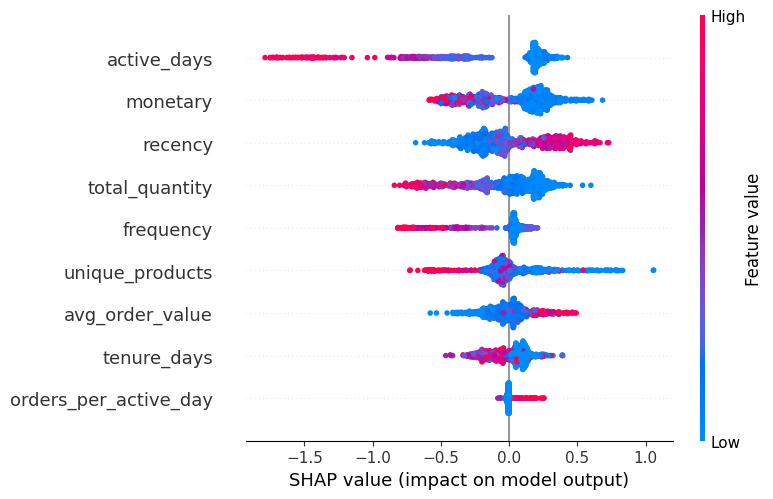

In [4]:
# 4. SHAP Feature Importance
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=features)
